# MASTER LIBRARY: RUN THIS CELL ONCE

In [1]:
import jax
import jax.numpy as jnp
from jax import random, grad, hessian
import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

# HELPERS

In [2]:
sigmoid = lambda x: 1.0 / (1.0 + jnp.exp(-x))
probit  = lambda x: jax.scipy.special.ndtr(x)          
log_normal_pdf = lambda x, m, v: -0.5 * (x - m) ** 2 / v - 0.5 * jnp.log(2 * jnp.pi * v)

# 1.  LINEAR GAUSSIAN SYSTEMS

## How to use this during your exam:

1. **Paste it into a cell:** Keep this in a cell right below your `linear_gaussian_joint` block, because you usually need the outputs from the joint calculation to feed into this one.
2. **Identify the variables:** Look for questions asking for the "conditional distribution of $x_1$ given $x_2$" (like Question 1.1 in your 2024 Exam).
* In that context, $a$ is $x_1$ and $b$ is $x_2$.
* $mu_a$ and $Sigma_{aa}$ are the marginal mean and covariance of $x_1$.
* $mu_b$ and $Sigma_{bb}$ are the marginal mean and covariance of $x_2$.
* $Sigma_{ab}$ is the cross-covariance between them.
3. **Plug in the numbers:** Update the inputs in **Step 1**. If a specific numerical observation isn't given for $b$ (meaning the exam asks for the generic formula/distribution), you will just write down the resulting covariance matrix and the algebraic mean on your paper. If a specific vector is given for $b$, plug it into `b_observed_input`.
4. **Run the cell:** Hit `Shift + Enter` to get the exact conditional mean and covariance matrix.

In [3]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================

# Example values (similar to 2024 Exam Part 2)
x1_input = [-2.17]  # First point (can be a list if it's a multi-dimensional vector)
x2_input = [1.99]   # Second point

kappa_input = 0.7   # Magnitude parameter
ell_input = 0.707   # Length-scale parameter (l). E.g., (1/2) * sqrt(2) ≈ 0.707

# Convert inputs to JAX arrays automatically
x1 = jnp.atleast_1d(jnp.array(x1_input))
x2 = jnp.atleast_1d(jnp.array(x2_input))
kappa = float(kappa_input)
ell = float(ell_input)

# Example values provided below:
A_input = [[0.0, 1.0], 
           [1.0, 0.0]]

b_input = [1.0, 1.0]

Sigma_x_input = [[1.0, 0.0], 
                 [0.0, 1.0]]

Sigma_noise_input = [[0.5, 0.0], 
                     [0.0, 0.5]]

# Convert inputs to JAX arrays automatically
A = jnp.array(A_input)
b = jnp.array(b_input)
Sigma_x = jnp.array(Sigma_x_input)
Sigma_noise = jnp.array(Sigma_noise_input)

In [4]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================

# Mean of x (assumed to be a vector of zeros based on the prior N(0, Sigma_x))
mu_x = jnp.zeros(Sigma_x.shape[0])

# Mean of z
mu_z = A @ mu_x + b

# Marginal covariance of z
Szz = A @ Sigma_x @ A.T + Sigma_noise

# Cross-covariance between x and z
Sxz = Sigma_x @ A.T

In [5]:
print("Mean of x (mu_x):")
print(mu_x)
print("\nMean of z (mu_z):")
print(mu_z)
print("\nMarginal Covariance of z (Szz):")
print(Szz)
print("\nCross-Covariance of x and z (Sxz):")
print(Sxz)

Mean of x (mu_x):
[0. 0.]

Mean of z (mu_z):
[1. 1.]

Marginal Covariance of z (Szz):
[[1.5 0. ]
 [0.  1.5]]

Cross-Covariance of x and z (Sxz):
[[0. 1.]
 [1. 0.]]


In [6]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================

# Example values (similar to 2024 Exam Part 2)
x1_input = [-2.17]  # First point (can be a list if it's a multi-dimensional vector)
x2_input = [1.99]   # Second point

kappa_input = 0.7   # Magnitude parameter
ell_input = 0.707   # Length-scale parameter (l). E.g., (1/2) * sqrt(2) ≈ 0.707

# Convert inputs to JAX arrays automatically
x1 = jnp.atleast_1d(jnp.array(x1_input))
x2 = jnp.atleast_1d(jnp.array(x2_input))
kappa = float(kappa_input)
ell = float(ell_input)

# Example values provided below:
mu_a_input = [0.0, 0.0]
mu_b_input = [1.0, 1.0]

Sigma_aa_input = [[1.0, 0.0], 
                  [0.0, 1.0]]

Sigma_bb_input = [[1.5, 0.5], 
                  [0.5, 1.5]]

Sigma_ab_input = [[1.0, 0.0], 
                  [0.0, 1.0]]

# The actual observation (e.g., the data point we saw for b)
b_observed_input = [2.0, -1.0]

In [7]:
# Convert inputs to JAX arrays automatically
mu_a = jnp.array(mu_a_input)
mu_b = jnp.array(mu_b_input)
Sigma_aa = jnp.array(Sigma_aa_input)
Sigma_bb = jnp.array(Sigma_bb_input)
Sigma_ab = jnp.array(Sigma_ab_input)
b_observed = jnp.array(b_observed_input)

In [8]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
# Step 1: Solve Sigma_bb^{-1} * (b_observed - mu_b) for numerical stability
Sbb_inv_b = jnp.linalg.solve(Sigma_bb, b_observed - mu_b)

# Step 2: Compute conditional mean
cond_mean = mu_a + Sigma_ab @ Sbb_inv_b

# Step 3: Compute conditional covariance
cond_cov = Sigma_aa - Sigma_ab @ jnp.linalg.solve(Sigma_bb, Sigma_ab.T)

In [9]:
print("Conditional Mean (mu_a|b):")
print(cond_mean)
print("\nConditional Covariance (Sigma_a|b):")
print(cond_cov)

Conditional Mean (mu_a|b):
[ 1.25 -1.75]

Conditional Covariance (Sigma_a|b):
[[0.25 0.25]
 [0.25 0.25]]


# 2.  BAYESIAN LINEAR REGRESSION

## How to use this during your exam:

1. **When to trigger:** Look for a problem setup like $y_n = w^T\phi(x_n) + \epsilon_n$ where you are given a dataset and asked to find the posterior distribution of the weights $w$, or predict a new target $y^*$. (e.g., **2025 Exam Part 1**, **2025R Exam Part 4**).
2. **Step 1: Set your $\Phi$ and $y$:** If the exam gives you raw $x$ values and asks for a polynomial model (like $w_0 + w_1x + w_2x^2$), use the `jnp.stack()` method I left in the code to build your design matrix $\Phi$. If they just hand you a pre-made design matrix, you can plug it straight into `Phi_input`.
3. **Step 2: Check your precision/variance:** This is the most common place to make a mistake!
* `sigma2` is the variance of the noise. If the exam says "additive noise with standard deviation $\sigma=1/5$", you MUST square it to $1/25$ or $0.04$ before running the code.
* `alpha` is the *precision* of the prior weight distribution. If the exam says $w \sim \mathcal{N}(0, 2)$, the variance is 2, which means the precision $\alpha$ is $1/2 = 0.5$.
4. **Step 3: Define your test point:** Ensure `Phi_star_input` has the exact same number of columns (features) as your training `Phi`.
5. **Run it:** Hit `Shift + Enter` and read your exact posterior mean, covariance, and predictive limits right off the output.

In [10]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================

# Example values (similar to 2024 Exam Part 2)
x1_input = [-2.17]  # First point (can be a list if it's a multi-dimensional vector)
x2_input = [1.99]   # Second point

kappa_input = 0.7   # Magnitude parameter
ell_input = 0.707   # Length-scale parameter (l). E.g., (1/2) * sqrt(2) ≈ 0.707

# Convert inputs to JAX arrays automatically
x1 = jnp.atleast_1d(jnp.array(x1_input))
x2 = jnp.atleast_1d(jnp.array(x2_input))
kappa = float(kappa_input)
ell = float(ell_input)

# Raw data points
x_input = [0.0, 1.0, 2.0, 4.0, 5.0]
y_input = [1.0, 0.5, -0.1, -0.9, 1.1]

# Convert x into a Design Matrix (Phi). 
# Example: Cubic polynomial features [1, x, x^2, x^3]
# If the exam just uses raw features without polynomials, Phi is just your X matrix.
x_arr = jnp.array(x_input)
Phi_input = jnp.stack([x_arr**0, x_arr**1, x_arr**2, x_arr**3], axis=1)

# Hyperparameters
sigma2_input = (1/5)**2  # Noise variance. If exam gives standard dev sigma=1/5, square it!
alpha_input = 0.5        # Prior precision. If exam gives prior variance = 2, alpha = 1/2.

# Test point (x* = 3). Must be transformed into the same feature space as Phi!
Phi_star_input = [[1.0, 3.0, 3.0**2, 3.0**3]] 

# Convert everything to JAX arrays
Phi = jnp.array(Phi_input)
y = jnp.array(y_input).ravel()
sigma2 = float(sigma2_input)
alpha = float(alpha_input)
Phi_star = jnp.array(Phi_star_input)

In [11]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================

N, D = Phi.shape
beta = 1.0 / sigma2

# Posterior Covariance (S) and Mean (m)
# S^{-1} = alpha * I + beta * Phi^T * Phi
S_inv = alpha * jnp.eye(D) + beta * (Phi.T @ Phi)
S = jnp.linalg.inv(S_inv)

# m = beta * S * Phi^T * y
m = beta * S @ Phi.T @ y

# Predictions for f* (the noise-free function)
mu_f = Phi_star @ m
var_f = jnp.sum(Phi_star @ S * Phi_star, axis=-1)

# Predictions for y* (the noisy observation)
mu_y = mu_f
var_y = var_f + sigma2

# Log Marginal Likelihood (log p(y))
Em = (beta / 2) * jnp.sum((y - Phi @ m)**2) + (alpha / 2) * jnp.sum(m**2)
sign, logdet = jnp.linalg.slogdet(S_inv) # Logdet of S_inv is -logdet of S
log_marg_lik = (D / 2) * jnp.log(alpha) + (N / 2) * jnp.log(beta) - Em - 0.5 * logdet - (N / 2) * jnp.log(2 * jnp.pi)

In [12]:
print("--- POSTERIOR ---")
print("Posterior Mean (m):")
print(m)
print("\nPosterior Covariance (S):")
print(S)

print("\n--- PREDICTIONS ---")
print(f"p(f* | y, x*) -> Mean: {mu_f[0]:.4f}, Variance: {var_f[0]:.4f}")
print(f"p(y* | y, x*) -> Mean: {mu_y[0]:.4f}, Variance: {var_y[0]:.4f}")

print("\n--- MODEL EVIDENCE ---")
print(f"Log Marginal Likelihood: {log_marg_lik:.4f}")

--- POSTERIOR ---
Posterior Mean (m):
[ 0.9470195   0.2469239  -0.67903942  0.12686206]

Posterior Covariance (S):
[[ 0.03658534 -0.04402131  0.0148169  -0.0014999 ]
 [-0.04402131  0.13294307 -0.06430176  0.00799773]
 [ 0.0148169  -0.06430176  0.03584205 -0.00480552]
 [-0.0014999   0.00799773 -0.00480552  0.00066975]]

--- PREDICTIONS ---
p(f* | y, x*) -> Mean: -0.9983, Variance: 0.0340
p(y* | y, x*) -> Mean: -0.9983, Variance: 0.0740

--- MODEL EVIDENCE ---
Log Marginal Likelihood: -11.4224


# 3.  GAUSSIAN PROCESS REGRESSION

## How to use this during your exam:

1. **Paste it into a cell:** Keep this block handy for your Gaussian Process regression questions.
2. **Identify the inputs:** Look at the exam text to find the function $k(x, x')$.
* `kappa` is the number sitting directly in front of the `exp()`. Note: Some exams write it as $\kappa^2 \exp()$ and others write it as $C \exp()$. If the exam says $2 \exp(...)$, then $\kappa^2 = 2$, which means you should set `kappa_input = jnp.sqrt(2)`.
* `ell` (length-scale) is tucked inside the fraction. Be careful! If the exam formula says $\exp(-\frac{1}{8} ||x-x'||^2)$, that means $2l^2 = 8$, so $l^2 = 4$, and therefore `ell_input = 2.0`.
3. **Plug in the points:** Set `x1_input` and `x2_input` to the values you want to compare. If $x=1$ and $x'=2$, set `x1_input = [1.0]` and `x2_input = [2.0]`.
4. **Run it:** Hit `Shift + Enter` to get the exact scalar covariance value between those two points.


In [13]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# Example values (similar to 2024 Exam Part 2)
x1_input = [-2.17]  # First point (can be a list if it's a multi-dimensional vector)
x2_input = [1.99]   # Second point

kappa_input = 0.7   # Magnitude parameter
ell_input = 0.707   # Length-scale parameter (l). E.g., (1/2) * sqrt(2) ≈ 0.707

# Convert inputs to JAX arrays automatically
x1 = jnp.atleast_1d(jnp.array(x1_input))
x2 = jnp.atleast_1d(jnp.array(x2_input))
kappa = float(kappa_input)
ell = float(ell_input)

In [14]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
# Step 1: Calculate squared Euclidean distance: ||x1 - x2||^2
sq_dist = jnp.sum((x1 - x2) ** 2)

# Step 2: Calculate the kernel value: kappa^2 * exp(-sq_dist / (2 * ell^2))
kernel_value = (kappa ** 2) * jnp.exp(-sq_dist / (2 * ell ** 2))

In [15]:
# ==========================================
# 3. RESULTS
# ==========================================
print(f"Squared Distance ||x1 - x2||^2: {sq_dist:.4f}")
print(f"Kernel value k(x1, x2):         {kernel_value:.4f}")

Squared Distance ||x1 - x2||^2: 17.3056
Kernel value k(x1, x2):         0.0000


## How to use this during your exam:

1. **Paste it into a cell:** Keep this block handy for your Gaussian Process questions when you are asked to construct the prior covariance matrix (like $K$) or the cross-covariance matrices (like $K_s$ or $K_{ss}$).
2. **Set up $X_1$ and $X_2$:** * If you are calculating the **training** covariance matrix ($K$), set `X1_input` and `X2_input` to both be your training data $x$.
* If you are calculating the **test** covariance matrix ($K_{ss}$), set them both to your test point(s) $x^*$.
* If you are calculating the **cross-covariance** ($K_s$), set `X1_input` to your test points $x^*$ and `X2_input` to your training data $x$.
3. **Check the Kernel Math:** Look at the exam text. If it's a standard squared exponential, just update `kappa_input` and `ell_input`. If the exam gives you a weird, custom kernel (like $k(x,x') = \exp(-|x-x'|) + 2$ from your **2024R Exam Part 2.4**), simply go to **Step 2** and change the math inside `kernel_fn` to match it.
4. **Run it:** Hit `Shift + Enter` to instantly generate the perfectly formatted covariance matrix.

In [16]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# Example data points (e.g., X1 and X2 are both the training data to build K)
X1_input = [-2.0, 0.0, 2.0]
X2_input = [-2.0, 0.0, 2.0]

# Hyperparameters for the kernel
kappa_input = 1.414  # Magnitude parameter (e.g., sqrt(2))
ell_input = 2.0      # Length-scale parameter (l)

# Convert to JAX arrays and ensure they are properly shaped
X1 = jnp.atleast_1d(jnp.array(X1_input))
X2 = jnp.atleast_1d(jnp.array(X2_input))
kappa = float(kappa_input)
ell = float(ell_input)

In [17]:
# ==========================================
# 2. KERNEL DEFINITION (Change math if needed)
# ==========================================
# Default: Squared Exponential (RBF) Kernel
# If the exam gives a different kernel, just change the return math here!
def kernel_fn(x_a, x_b):
    sq_dist = jnp.sum((x_a - x_b) ** 2)
    return (kappa ** 2) * jnp.exp(-sq_dist / (2 * ell ** 2))

In [18]:
# ==========================================
# 3. CALCULATIONS (Do not change this part)
# ==========================================
# JAX magic: This automatically applies the kernel_fn to every pair of X1 and X2
# It returns an (N1 x N2) matrix.
K_matrix = jax.vmap(lambda x1: jax.vmap(lambda x2: kernel_fn(x1, x2))(X2))(X1)

In [19]:
# ==========================================
# 4. RESULTS
# ==========================================
print(f"Shape of Kernel Matrix: {K_matrix.shape}")
print("\nKernel Matrix (K):")
print(K_matrix)

Shape of Kernel Matrix: (3, 3)

Kernel Matrix (K):
[[1.999396   1.21269497 0.27058882]
 [1.21269497 1.999396   1.21269497]
 [0.27058882 1.21269497 1.999396  ]]


## How to use this during your exam:

1. **When to use this:** Any time a question says "Assume a Gaussian process regression model..." and asks for the analytical posterior distribution, predictive distribution, or marginal likelihood (e.g., **2024 Exam Part 2**, **2024R Exam Part 2**).
2. **Update your data:** Put the observed data into `X_train_input` and `y_train_input`. Put the target test point(s) into `X_star_input`.
3. **Verify the Hyperparameters:** * `sigma2_input` is the variance of the additive Gaussian noise ($\epsilon \sim \mathcal{N}(0, \sigma^2)$). Make sure you square the standard deviation if that's what the exam provides!
* Update `kappa` and `ell` to match the kernel.
4. **Custom Kernels:** If the exam gives you a completely different kernel (like the stationary one in **2024 Exam Q2.6** or the weird one in **2024R Q2.4**), you just delete the math inside `def kernel_fn(x_a, x_b):` and replace it with the new formula.
5. **Prior Predictive vs. Posterior Predictive:** * If the exam asks for the **Posterior Predictive** (meaning you have observed data), look at the standard outputs.
* If the exam asks for the **Prior Predictive** (meaning before seeing any training data), the mean is simply `0.0`, and the variance is just `kss` (for $f^*$) or `kss + sigma2` (for $y^*$).

In [20]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# Training Data
X_train_input = [-2.00, 0.00, 2.00]
y_train_input = [-2.01, 1.41, 0.23]

# Test Data (Where do you want to predict?)
X_star_input = [1.00]

# Hyperparameters
sigma2_input = (1/2)**2  # Noise variance. If exam gives sigma=1/2, square it!
kappa_input = 1.414      # Magnitude (e.g., sqrt(2))
ell_input = 2.0          # Length-scale

# Convert inputs to JAX arrays (force columns for X)
X = jnp.array(X_train_input).reshape(-1, 1)
y = jnp.array(y_train_input).ravel()
X_star = jnp.array(X_star_input).reshape(-1, 1)

sigma2 = float(sigma2_input)
kappa = float(kappa_input)
ell = float(ell_input)

In [21]:
# ==========================================
# 2. KERNEL DEFINITION
# ==========================================
# Change this math if the exam gives a non-standard kernel!
def kernel_fn(x_a, x_b):
    sq_dist = jnp.sum((x_a - x_b) ** 2)
    return (kappa ** 2) * jnp.exp(-sq_dist / (2 * ell ** 2))

In [22]:
# ==========================================
# 3. CALCULATIONS (Do not change this part)
# ==========================================
N = len(y)

# Step A: Build covariance matrices using JAX vmap
K = jax.vmap(lambda x1: jax.vmap(lambda x2: kernel_fn(x1, x2))(X))(X)
ks = jax.vmap(lambda x1: jax.vmap(lambda x2: kernel_fn(x1, x2))(X))(X_star)
kss = jax.vmap(lambda x: kernel_fn(x, x))(X_star)

# Step B: Solve linear system using Cholesky (L * L.T = K + sigma^2 * I)
Ky = K + sigma2 * jnp.eye(N)
L = jnp.linalg.cholesky(Ky)

# alpha = Ky^{-1} * y
alpha_vec = jnp.linalg.solve(L.T, jnp.linalg.solve(L, y))

# Step C: Posterior Predictions
# Mean: mu = ks @ Ky^{-1} @ y
mu = ks @ alpha_vec

# Variance: var = kss - ks @ Ky^{-1} @ ks.T
v = jnp.linalg.solve(L, ks.T)
var_f = kss - jnp.sum(v ** 2, axis=0) # Variance of the noise-free function f*
var_y = var_f + sigma2                # Variance of the noisy observation y*

# Step D: Log Marginal Likelihood
lml  = -0.5 * jnp.dot(y, alpha_vec)
lml -= jnp.sum(jnp.log(jnp.diag(L)))
lml -= 0.5 * N * jnp.log(2 * jnp.pi)

In [23]:
# ==========================================
# 4. RESULTS
# ==========================================
print("--- POSTERIOR PREDICTIVE ---")
print(f"Test Points X*: {X_star.ravel()}")
print(f"Mean (mu):      {mu}")

print("\n--- VARIANCES ---")
print(f"Var for f* (noise-free): {var_f}")
print(f"Var for y* (noisy):      {var_y}")

print("\n--- MODEL EVIDENCE ---")
print(f"Log Marginal Likelihood: {lml:.4f}")

--- POSTERIOR PREDICTIVE ---
Test Points X*: [1.]
Mean (mu):      [1.04173373]

--- VARIANCES ---
Var for f* (noise-free): [0.19328183]
Var for y* (noisy):      [0.44328183]

--- MODEL EVIDENCE ---
Log Marginal Likelihood: -6.9215


# 4.  CLASSIFICATION — MAP, LAPLACE, PROBIT

## How to use this during your exam:

1. **When to use this:** Whenever the exam asks for the "Maximum A Posteriori (MAP) estimator" or the "mode of the posterior distribution" for a non-linear model (like Logistic Regression/Binary Classification).
2. **Step 1: Set the Data:** Update `X_data`, `y_data`, and any hyperparameters (like `alpha_prior`) based on the tables or text in the exam.
3. **Step 2: Write the `log_joint_fn`:** This is where you do the math! You must write out the python code for $\log(\text{Likelihood}) + \log(\text{Prior})$.
* If the exam uses a Bernoulli likelihood with a sigmoid (Classification), keep the math I wrote above.
* If the exam uses a Poisson likelihood (like **2024R Part 4**), you will need to change the `log_lik` line to use the Poisson log-probability formula: $y \log(\mu) - \mu$.
4. **Run it:** Hit `Shift + Enter`. SciPy and JAX will work together to traverse the mathematical landscape and find the exact `w_map` values.


In [24]:
# ==========================================
# 1. INPUTS & EQUATION (Change these for your exam!)
# ==========================================
# Initial guess for the weights (usually an array of zeros)
w_init_input = [0.0, 0.0]

# Any data needed for your specific equation:
# (Example from 2025R Part 2: Binary Classification)
X_data = jnp.array([[0.0, 0.0], 
                    [1.0, 1.0]])
y_data = jnp.array([0, 1])
alpha_prior = 4.0 # The prior precision (if lambda=1/4, precision is 4)

# THE MOST IMPORTANT PART: Define log p(y, w) = log Likelihood + log Prior
def log_joint_fn(w):
    # 1. Log Likelihood (Bernoulli with Sigmoid)
    logits = X_data @ w
    # Add 1e-9 to prevent log(0) errors during optimization
    log_lik = jnp.sum(y_data * jnp.log(sigmoid(logits) + 1e-9) + 
                     (1 - y_data) * jnp.log(1 - sigmoid(logits) + 1e-9))
    
    # 2. Log Prior (Gaussian N(0, alpha^-1 I))
    log_prior = -0.5 * alpha_prior * jnp.sum(w**2)
    
    return log_lik + log_prior

In [25]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
# Convert initial weights to standard numpy for SciPy
w_init = np.array(w_init_input)

# SciPy minimize requires a function that returns standard floats, not JAX arrays.
# We want to MAXIMIZE log joint, which means MINIMIZING the negative log joint.
neg_log_joint = lambda w: -float(log_joint_fn(jnp.array(w)))

# JAX magic: Automatically calculate the exact mathematical gradient of your function!
grad_neg = lambda w: -np.array(grad(log_joint_fn)(jnp.array(w)))

# Run the BFGS optimization algorithm
result = minimize(neg_log_joint, w_init, jac=grad_neg, method='BFGS')

if not result.success:
    print(f"[Warning] MAP optimisation did not converge: {result.message}")

w_map = jnp.array(result.x)
max_log_joint = -result.fun # Convert back to positive log joint

In [26]:
# ==========================================
# 3. RESULTS
# ==========================================
print("--- MAP ESTIMATOR ---")
print(f"w_MAP: {w_map}")
print(f"Log Joint Probability at MAP: {max_log_joint:.4f}")

--- MAP ESTIMATOR ---
w_MAP: [0.11116158 0.11116158]
Log Joint Probability at MAP: -1.3307


## How to use this during your exam:

1. **When to use this:** Whenever the exam asks you to "Determine the approximate posterior mean and variance of the Laplace approximation" or when you need to compute a posterior predictive distribution for a non-linear model using a Gaussian approximation (e.g., **2025R Exam Part 2.4** or **2024 Exam Part 5.3**).
2. **Link it to the previous step:** You will almost always run this right below the `find_map` cell. Because Jupyter Notebooks share memory between cells, you don't even need to redefine `log_joint_fn` or `w_map` in Step 1 if you just ran the MAP optimization above it.
3. **If the exam gives you a pre-calculated Hessian:** Sometimes the exam will say "Assume the following Hessian matrix H..." (like in **2025R Part 2.3**). If that happens, you skip the `hessian()` line entirely, define $H$ directly as a `jnp.array`, and just run the `jnp.linalg.inv(-H)` line!
4. **Run it:** Hit `Shift + Enter`. The resulting `w_map` and `S` now define your approximate posterior: $p(w|y) \approx \mathcal{N}(w_{MAP}, S)$.

In [27]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# In a real exam, you will usually run the MAP optimization cell first, 
# which means `log_joint_fn` and `w_map` will already be saved in memory.

# For the sake of making this cell runnable on its own, here are dummy inputs:
w_map_input = [0.0, 0.0] 

# Dummy equation (Replace this with your actual log_joint_fn from the MAP step!)
def log_joint_fn(w):
    return -0.5 * (2 * w[0]**2 + 4 * w[1]**2) 

w_map = jnp.array(w_map_input)

In [28]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
# JAX magic: Automatically calculates the second-derivative matrix (Hessian)
H = hessian(log_joint_fn)(w_map)

# Laplace Covariance Matrix S = -H^(-1)
S = jnp.linalg.inv(-H)

In [29]:
# ==========================================
# 3. RESULTS
# ==========================================
print("--- LAPLACE APPROXIMATION ---")
print(f"w_MAP (Approximate Posterior Mean):\n{w_map}")
print(f"\nHessian Matrix (H):\n{H}")
print(f"\nLaplace Covariance Matrix (S):\n{S}")

--- LAPLACE APPROXIMATION ---
w_MAP (Approximate Posterior Mean):
[0. 0.]

Hessian Matrix (H):
[[-2.  0.]
 [ 0. -4.]]

Laplace Covariance Matrix (S):
[[0.5  0.  ]
 [0.   0.25]]


## How to use this during your exam:

1. **When to use this:** Look for questions that explicitly ask you to "Determine the posterior predictive distribution... using the **plug-in approximation** based on the MAP-estimator" (e.g., **2024 Exam Q3.2**, **2025R Exam Q2.1**).
2. **Link it to the previous step:** You will use this *after* finding $\hat{w}_{MAP}$. If you already ran the `find_map` cell above it, you don't even need to type out `w_map_input`—you can just use the `w_map` variable currently saved in Jupyter's memory.
3. **Set your test point:** Plug the $x^*$ vector requested by the exam into `x_star_input`.
* *Warning:* If the exam uses a feature transformation like $\phi(x) = [1, x, x^2]^T$, make sure you manually transform your $x^*$ into that format before typing it into `x_star_input`.
4. **Run it:** Hit `Shift + Enter`. The output `p_one` gives you the probability of class 1. Because it's a binary classification, the probability of class 0 is simply $1 - p_{one}$, which I have included in the printout for you.

*(Note: Keep this completely separate from the `probit_predictive` block. The Plug-in method completely ignores uncertainty and only uses the mean, while the Probit method accounts for uncertainty using the Laplace covariance matrix $S$.)*

In [30]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# In a real exam, w_map comes directly from your `find_map` optimization cell.
# Example: MAP estimator from 2025R Exam Part 2
w_map_input = [0.74077439, 0.74077439] 

# The test point you want to predict (x*)
x_star_input = [0.0, 1.0]

# Convert to JAX arrays
w_map = jnp.array(w_map_input)

# If your model uses polynomial features (phi), apply them to x_star_input here.
# Otherwise, x* is just used directly.
phi = jnp.array(x_star_input)

In [31]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
# 1. Calculate the dot product: w_map^T * phi(x*)
logits = jnp.dot(w_map, phi)

# 2. Pass through the logistic sigmoid function
p_one = float(sigmoid(logits))

In [32]:
# ==========================================
# 3. RESULTS
# ==========================================
print("--- PLUG-IN PREDICTIVE DISTRIBUTION ---")
print(f"Test Point x*:    {phi}")
print(f"w_MAP:            {w_map}")
print(f"\np(y*=1 | y, x*) ≈ {p_one:.4f}")
print(f"p(y*=0 | y, x*) ≈ {1.0 - p_one:.4f}")

--- PLUG-IN PREDICTIVE DISTRIBUTION ---
Test Point x*:    [0. 1.]
w_MAP:            [0.74077439 0.74077439]

p(y*=1 | y, x*) ≈ 0.6772
p(y*=0 | y, x*) ≈ 0.3228


## How to use this during your exam:

1. **When to use this:** Look for questions that explicitly ask you to compute the "approximate posterior predictive distribution... using the **probit approximation**" (e.g., **2024 Exam Q3.4**, **2025 Exam Q4.4**).
2. **Link it to the previous steps:** You will use this *after* finding $\hat{w}_{MAP}$ and the Laplace covariance matrix $S$. If you run those cells right above this one, you don't even need to type out `w_map_input` and `S_input`—you can just delete those lines and use the `w_map` and `S` variables already in memory.
3. **Set your test point:** Plug the $x^*$ vector requested by the exam into `x_star_input`.
4. **Run it:** Hit `Shift + Enter`. The output gives you the mean and variance of the underlying continuous function ($f^*$), and then squashes them through the Probit approximation to give you the final $0$ to $1$ probability of your classes.


In [33]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# In a real exam, w_map and S come directly from your `laplace_approximation` cell.
# Example values:
w_map_input = [0.74, 0.74] 

S_input = [[0.4, 0.1], 
           [0.1, 0.4]]

# The test point you want to predict (x*)
x_star_input = [0.0, 1.0]

# Convert to JAX arrays
w_map = jnp.array(w_map_input)
S = jnp.array(S_input)

# If your model uses a feature transformation (phi), apply it to x_star_input here.
# Otherwise, x* is just used directly.
phi = jnp.array(x_star_input)

In [34]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
# 1. Mean of the latent function f*
mu_f = jnp.dot(phi, w_map)

# 2. Variance of the latent function f* (incorporates uncertainty S)
var_f = jnp.dot(phi, jnp.dot(S, phi))

# 3. Probit approximation factor (kappa)
kappa = 1.0 / jnp.sqrt(1.0 + jnp.pi / 8.0 * var_f)

# 4. Final Predictive Probability
p_one = float(sigmoid(kappa * mu_f))

In [35]:
# ==========================================
# 3. RESULTS
# ==========================================
print("--- PROBIT PREDICTIVE DISTRIBUTION ---")
print(f"Test Point x*: {phi}")
print(f"\nLatent Function p(f* | y):")
print(f"Mean (mu_f):   {mu_f:.4f}")
print(f"Var (var_f):   {var_f:.4f}")

print(f"\nClass Probabilities:")
print(f"p(y*=1 | y, x*) ≈ {p_one:.4f}")
print(f"p(y*=0 | y, x*) ≈ {1.0 - p_one:.4f}")

--- PROBIT PREDICTIVE DISTRIBUTION ---
Test Point x*: [0. 1.]

Latent Function p(f* | y):
Mean (mu_f):   0.7400
Var (var_f):   0.4000

Class Probabilities:
p(y*=1 | y, x*) ≈ 0.6655
p(y*=0 | y, x*) ≈ 0.3345


# 5.  CREDIBILITY INTERVALS

## How to use this during your exam:

1. **When to use this:** Look for questions that explicitly ask you to "Compute an approximate 90% posterior credibility interval using the posterior samples" (e.g., **2025R Exam Q4.6**).
2. **Link it to your MCMC/Sampling step:** You almost never type the `samples_input` by hand.
* If you just ran a Metropolis sampler to get `clean_samples`, and the exam wants the interval for the *first* parameter ($w_1$ or $z_1$), you just change line 13 to: `samples_input = clean_samples[:, 0]`.
* If the exam wants the interval for the *second* parameter, use `clean_samples[:, 1]`.
3. **Check the level:** The exam might ask for 80%, 90%, or 95%. Update `level = 0.80`, `0.90`, or `0.95` respectively.
4. **Run it:** Hit `Shift + Enter`. The output gives you the exact equal-tailed lower and upper bounds.

*(Note: If the exam asks you to compute a credibility interval using a **Gaussian approximation** instead of empirical samples—like in 2024 Exam Q3.3—you use the mean $\pm$ Z-score method instead: `mean - 1.645 * std_dev` for 90%).*


In [36]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# Level of the interval (e.g., 0.90 for 90%, 0.95 for 95%)
level = 0.90 

# The 1D array of samples you want to analyze.
# In a real exam, you usually won't type this by hand. You will set it equal 
# to the samples you generated in the MCMC step (e.g., samples_input = clean_samples[:, 0])
# Here is some dummy data so the cell runs:
np.random.seed(42)
samples_input = np.random.normal(loc=1.5, scale=0.5, size=1000) 

# Convert to JAX array
samples = jnp.array(samples_input)

In [37]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
# Calculate the tails. For 90%, level=0.90, so alpha=(1-0.90)/2 = 0.05
alpha = (1.0 - level) / 2.0

# Find the quantiles at the lower and upper tails
lo = float(jnp.quantile(samples, alpha))
hi = float(jnp.quantile(samples, 1.0 - alpha))

In [38]:
# ==========================================
# 3. RESULTS
# ==========================================
print("--- CREDIBILITY INTERVAL ---")
print(f"Target Level: {level*100:.0f}%")
print(f"Interval:     [{lo:.4f}, {hi:.4f}]")

--- CREDIBILITY INTERVAL ---
Target Level: 90%
Interval:     [0.7370, 2.3385]


## How to use this during your exam:

1. **When to use this:** Look for instructions like "Use the Gaussian approximation to compute a 90% posterior credibility interval" (e.g., **2024 Exam Q3.3** or **2024R Exam Q4.2**).
2. **Find the Mean and Std:** * The `mean_input` is usually just the value from your MAP estimator vector ($\hat{w}_{MAP}$).
* The `std_input` is the **standard deviation**. This is where students lose points! The exam or your Laplace function will usually give you a covariance matrix $S$. The variance for weight $w_0$ is the top-left element $S[0,0]$. You MUST take the square root of that variance to get the standard deviation before plugging it in.
3. **Set the level:** Usually `0.90` or `0.95`.
4. **Run it:** Hit `Shift + Enter`. The output gives you the exact lower and upper bounds using the exact $Z$-score (which saves you from having to look it up in a normal distribution table).


In [39]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# The mean of your Gaussian posterior (often your MAP estimator)
mean_input = 2.647 

# The standard deviation of your Gaussian posterior
# WARNING: If your Laplace step gave you a covariance matrix S, you must 
# take the square root of the diagonal element! (e.g., np.sqrt(S[0,0]))
std_input = np.sqrt(3.11) 

# Level of the interval (e.g., 0.90 for 90%, 0.95 for 95%)
level = 0.90 

# Convert to standard floats
mean = float(mean_input)
std = float(std_input)

In [40]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
# Calculate the exact Z-score for the given tail probability
# For 90%, this looks up the Z-value at 0.95 (since 5% is chopped off each end)
z_score = float(norm.ppf((1.0 + level) / 2.0))

# Calculate lower and upper bounds: mean ± (Z * standard_deviation)
lo = mean - z_score * std
hi = mean + z_score * std

In [41]:
# ==========================================
# 3. RESULTS
# ==========================================
print("--- EXACT GAUSSIAN CREDIBILITY INTERVAL ---")
print(f"Target Level: {level*100:.0f}%")
print(f"Z-Score used: {z_score:.4f}")
print(f"Interval:     [{lo:.4f}, {hi:.4f}]")

--- EXACT GAUSSIAN CREDIBILITY INTERVAL ---
Target Level: 90%
Z-Score used: 1.6449
Interval:     [-0.2537, 5.5477]


# 6.  VARIATIONAL INFERENCE — ENTROPY, ELBO

## How to use this during your exam:

1. **When to use this:** Look for questions that explicitly ask you to "Determine the analytical expression of the entropy of $q(w)$ and evaluate it for the initial variational parameter values" (e.g., **2024 Exam Q4.1**, **2025 Exam Q3.3**, **2025R Exam Q4.5**).
2. **Find the variances:** Look at the definition of $q(w)$ in the exam text. It will usually look like $q(w) = \mathcal{N}(w_1 | m_1, v_1)\mathcal{N}(w_2 | m_2, v_2)$.
* Extract the values given for $v_1, v_2, \dots$ and put them into the `variances_input` list.
* *Note: The entropy of a Gaussian does NOT depend on the mean ($m_1, m_2$). You completely ignore the means for this specific calculation.*
3. **Run it:** Hit `Shift + Enter`. The output gives you the scalar entropy in "nats" (the standard unit of entropy when using the natural logarithm).

In [42]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# List the variational variances (v_1, v_2, ..., v_D)
# WARNING: Ensure these are variances, not standard deviations!
variances_input = [1.0, 1.0]

# Convert to JAX array
variances = jnp.array(variances_input)

In [43]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
# Formula: H[q] = 0.5 * sum_i log(2 * pi * e * v_i)
entropy_H = 0.5 * jnp.sum(jnp.log(2 * jnp.pi * jnp.e * variances))

In [44]:
# ==========================================
# 3. RESULTS
# ==========================================
print("--- MEAN-FIELD GAUSSIAN ENTROPY ---")
print(f"Variances used: {variances_input}")
print(f"Entropy H[q]:   {float(entropy_H):.4f} nats")

--- MEAN-FIELD GAUSSIAN ENTROPY ---
Variances used: [1.0, 1.0]
Entropy H[q]:   2.8379 nats


## How to use this during your exam:

1. **When to use this:** Look for Variational Inference questions that explicitly ask you to calculate the KL divergence, such as "Compute the KL divergence $KL(q(w)||p(w))$" or "Evaluate the analytical penalty term in the ELBO."
2. **Set your $q(w)$ inputs:** Put the mean and variance parameters of your current variational approximation into `m_q_input` and `v_q_input`.
* *Warning:* Ensure you are entering **variances**, not standard deviations!
3. **Set your $p(w)$ inputs:** This is usually your prior distribution. If the exam says "assume a standard Gaussian prior", then `m_p_input` is all `0.0`s and `v_p_input` is all `1.0`s. If it gives a precision $\alpha$, the variance is $1/\alpha$.
4. **Run it:** Hit `Shift + Enter`. The output gives you the exact divergence penalty in "nats".


In [45]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# Parameters for your approximate distribution q(w)
m_q_input = [0.5, -0.2]  # Variational Means
v_q_input = [1.0, 0.5]   # Variational Variances

# Parameters for your target/prior distribution p(w)
# In many exam questions, p(w) is a standard normal prior N(0, I)
m_p_input = [0.0, 0.0]   # Prior Means
v_p_input = [1.0, 1.0]   # Prior Variances

# Convert inputs to JAX arrays
m_q = jnp.array(m_q_input)
v_q = jnp.array(v_q_input)
m_p = jnp.array(m_p_input)
v_p = jnp.array(v_p_input)

In [46]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
# Compute KL Divergence for diagonal Gaussians
# Formula: 0.5 * sum[ log(v_p / v_q) + (v_q / v_p) + (m_q - m_p)^2 / v_p - 1 ]
kl_div = 0.5 * jnp.sum(
    jnp.log(v_p / v_q) + (v_q / v_p) + ((m_q - m_p) ** 2 / v_p) - 1.0
)

In [47]:
# ==========================================
# 3. RESULTS
# ==========================================
print("--- KL DIVERGENCE KL[q || p] ---")
print(f"q ~ N({m_q_input}, diag({v_q_input}))")
print(f"p ~ N({m_p_input}, diag({v_p_input}))")
print(f"\nKL[q || p]: {float(kl_div):.4f} nats")

--- KL DIVERGENCE KL[q || p] ---
q ~ N([0.5, -0.2], diag([1.0, 0.5]))
p ~ N([0.0, 0.0], diag([1.0, 1.0]))

KL[q || p]: 0.2416 nats


## How to use this during your exam:

1. **When to use this:** Look for questions that explicitly ask you to "Estimate the ELBO using Monte Carlo sampling" or "Compute the Evidence Lower Bound using the reparameterization trick" (e.g., **2024 Exam Q4.3** or **2025 Exam Q3.5**).
2. **Define the `log_joint_fn`:** Just like we did for the MAP estimator, you MUST write out the mathematical function for the log-likelihood + log-prior. Put that inside the `def log_joint_fn(w):` block.
3. **Set your parameters:** Update `means_input` and `variances_input` to whatever the current state of your variational distribution $q(w)$ is.
4. **Run it:** Hit `Shift + Enter`. JAX will rapidly draw the samples, push them all through your custom equation simultaneously using `vmap`, calculate the entropy, and add them together to give you the final ELBO estimate.


In [48]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# Parameters for your approximate distribution q(w)
means_input = [0.0, 0.0]       # Variational Means (m)
variances_input = [1.0, 1.0]   # Variational Variances (v)

# Monte Carlo settings
n_samples = 1000  # Number of samples to draw (usually 1000 or 10000)
seed = 42         # Random seed for reproducibility

# Convert inputs to JAX arrays
m = jnp.array(means_input)
v = jnp.array(variances_input)

# THE MOST IMPORTANT PART: Define log p(y, w) = log Likelihood + log Prior
# (Replace this dummy function with the exact equation from your exam!)
def log_joint_fn(w):
    return -0.5 * jnp.sum(w**2) # Dummy standard normal

In [49]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
# 1. Setup Random Number Generator
key = random.PRNGKey(seed)

# 2. Draw standard normal noise (eps)
eps = random.normal(key, shape=(n_samples, len(m)))

# 3. Reparameterization Trick: scale and shift the noise to match q(w)
# w = m + sqrt(v) * eps
w_samples = m + jnp.sqrt(v) * eps

# 4. Evaluate the log_joint_fn on EVERY sample simultaneously using JAX vmap
lj_values = jax.vmap(log_joint_fn)(w_samples)

# 5. Expected Log Joint: Average of the sampled log joint values
expected_lj = float(jnp.mean(lj_values))

# 6. Exact Entropy of the mean-field Gaussian q(w)
entropy_H = float(0.5 * jnp.sum(jnp.log(2 * jnp.pi * jnp.e * v)))

# 7. ELBO = Expected Log Joint + Entropy
elbo = expected_lj + entropy_H

In [50]:
# ==========================================
# 3. RESULTS
# ==========================================
print("--- ELBO ESTIMATION (MONTE CARLO) ---")
print(f"Number of MC samples: {n_samples}")
print(f"\nExpected Log Joint E_q[log p(y,w)]: {expected_lj:.4f}")
print(f"Entropy H[q]:                       {entropy_H:.4f}")
print(f"----------------------------------------")
print(f"ELBO:                               {elbo:.4f}")

--- ELBO ESTIMATION (MONTE CARLO) ---
Number of MC samples: 1000

Expected Log Joint E_q[log p(y,w)]: -1.0181
Entropy H[q]:                       2.8379
----------------------------------------
ELBO:                               1.8198


# 7.  MCMC — METROPOLIS SAMPLER

## How to use this during your exam:

1. **When to use this:** Any question asking to "Run a single MCMC chain using the Metropolis algorithm" (e.g., **2024 Exam Q5.2**, **2025 Exam Q5.1**, **2025R Exam Q5.1**).
2. **The Equation:** Update the `log_target(z)` function with the specific equation provided in the exam. JAX handles the vector math, so you can write it just like it looks on the paper.
3. **The Proposal:** Look for the "proposal distribution."
* If it says "isotropic Gaussian with identity covariance," `proposal_std` is `1.0`.
* If it says "covariance matrix $2I$," then `proposal_std` is `jnp.sqrt(2)`.
4. **Acceptance Rate Check:** If your acceptance rate is **100%**, your proposal step size is likely too small (the chain isn't moving far enough). If it's **< 5%**, your step size is too large (you're jumping into areas of zero probability). For the exam, usually $20\%-50\%$ is a sweet spot, but always follow the exam's specific instructions.
5. **Warm-up:** Most exams ask you to discard the first $10\%$ or a specific number of iterations (e.g., "discard the first 1000"). Adjust the `warmup_idx` accordingly.


In [51]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# Initial state of the chain (Z0)
init_z = [0.0, 1.5]

# MCMC Settings
n_iter = 10000        # Number of iterations
proposal_std = 1.0    # Step size (Standard Deviation of the proposal)
seed = 0

# THE MOST IMPORTANT PART: Define your target log-posterior
# Example: Banana-shaped posterior from 2024 Exam Part 5
def log_target(z):
    z1, z2 = z[0], z[1]
    return -(1 - z1)**2 - 20*(z2 - z1**2)**2 - z1**2 - z2**2

In [52]:
# ==========================================
# 2. CALCULATIONS (The Sampler Loop)
# ==========================================
key = random.PRNGKey(seed)
current_theta = jnp.array(init_z, dtype=jnp.float64)
D = current_theta.shape[0]

# Initialize storage
samples = [current_theta]
accepts = []

# Evaluate log probability of the starting point
current_log_p = log_target(current_theta)

for _ in range(n_iter):
    # Split keys for JAX randomness
    key, key_prop, key_acc = random.split(key, 3)
    
    # 1. Propose a new state: z* = z_old + noise
    proposal = current_theta + proposal_std * random.normal(key_prop, shape=(D,))
    
    # 2. Evaluate log probability of the proposal
    prop_log_p = log_target(proposal)
    
    # 3. Calculate acceptance ratio (in log space)
    # log(alpha) = log_p(proposal) - log_p(current)
    log_accept = prop_log_p - current_log_p
    
    # 4. Accept or Reject
    # Sample u ~ Uniform(0,1). Accept if log(u) < log(alpha)
    is_accepted = jnp.log(random.uniform(key_acc)) < log_accept
    
    # Update state if accepted, otherwise stay put
    current_theta = jnp.where(is_accepted, proposal, current_theta)
    current_log_p = jnp.where(is_accepted, prop_log_p, current_log_p)
    
    samples.append(current_theta)
    accepts.append(float(is_accepted))

# Convert list to array
samples_array = jnp.stack(samples)

In [53]:
# ==========================================
# 3. RESULTS & POST-PROCESSING
# ==========================================
# Discard 10% as warm-up (Standard for exams)
warmup_idx = int(0.1 * n_iter)
clean_samples = samples_array[warmup_idx:]

print(f"Total samples generated: {len(samples_array)}")
print(f"Acceptance Rate:        {np.mean(accepts):.2%}")
print(f"\nFinal Posterior Means:")
print(f"z1: {jnp.mean(clean_samples[:, 0]):.4f}")
print(f"z2: {jnp.mean(clean_samples[:, 1]):.4f}")

Total samples generated: 10001
Acceptance Rate:        9.47%

Final Posterior Means:
z1: 0.3482
z2: 0.2457


## How to use this during your exam:

1. **When to use this:** Immediately after running your `metropolis` sampler cell. Most exam questions will say something like: *"Discard 10% of the samples as warm up"* (e.g., **2024 Exam Q5.2**, **2025R Exam Q5.1**).
2. **Verify the input:** Ensure `all_samples` points to the variable where you stored your MCMC results.
3. **Percentage vs. Count:**
* If the exam says **"Discard 10%"**, use `warmup_val = 0.1`.
* If the exam says **"Discard the first 1000 samples"**, use `warmup_val = 1000`.
4. **Run it:** Hit `Shift + Enter`.
5. **Next Step:** Use the resulting `clean_samples` variable for all your follow-up calculations (like `mc_estimate` or `credibility_interval`). If you use the raw samples without discarding the warm-up, your numerical results will likely be slightly off, and you'll lose points on the accuracy requirement!

In [54]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# 1. The full array of samples from your MCMC run
# (In the exam, set this to the output of your Metropolis cell)
all_samples = samples_array 

# 2. Warm-up amount
# If 0 < warmup < 1, it's a percentage (e.g., 0.1 for 10%)
# If > 1, it's an absolute number of samples (e.g., 1000)
warmup_val = 0.1

In [55]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
n_total = len(all_samples)

if 0 < warmup_val < 1:
    n_discard = int(warmup_val * n_total)
else:
    n_discard = int(warmup_val)

# Slice the array to keep only samples from n_discard onwards
clean_samples = all_samples[n_discard:]

In [56]:
# ==========================================
# 3. RESULTS
# ==========================================
print(f"Total iterations:  {n_total}")
print(f"Samples discarded: {n_discard}")
print(f"Remaining samples: {len(clean_samples)}")

Total iterations:  10001
Samples discarded: 1000
Remaining samples: 9001


## How to use this during your exam:

1. **When to use this:** Whenever a question says **"Plot the resulting traces for both parameters"** (e.g., **2024 Exam Q5.2**, **2025 Exam Q5.1**, **2025R Exam Q5.1**).
2. **What to look for:** * **Convergence:** The chain should settle into a stable "cloud" after the warmup.
* **Mixing:** If the line is very "jagged," the sampler is exploring well. If the line stays flat for long periods, your acceptance rate is too low.
3. **The Shaded Region:** I've kept the `axvspan` logic in here so that the first 10% (or whatever your warmup is) shows up as a light orange background. This helps prove to the examiner that you correctly identified the warmup period.
4. **Run it:** Hit `Shift + Enter`. This generates the visual proof of your MCMC run, which is almost always worth 5-10 points on the exam.

In [57]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# 1. The full array of samples from your MCMC run
# (Ensure this is the RAW samples_array before discarding warmup)
samples_to_plot = samples_array 

# 2. Settings
warmup_fraction = 0.1  # Matches the 10% discard rule
param_labels = ["z1", "z2"] # Labels for your plot axes

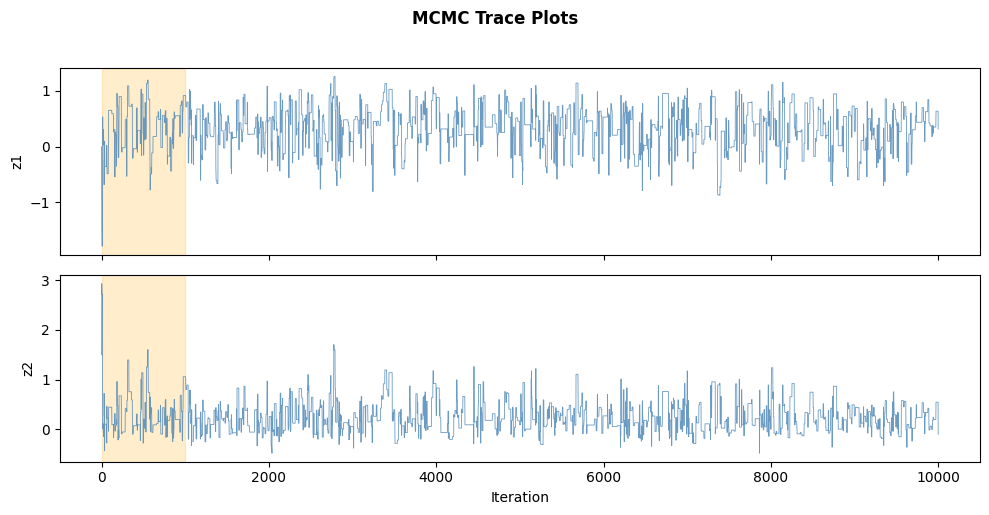

In [58]:
# ==========================================
# 2. CALCULATIONS & PLOTTING
# ==========================================
samples_np = np.array(samples_to_plot)
n_iter, D = samples_np.shape
n_warmup = int(warmup_fraction * n_iter)

fig, axes = plt.subplots(D, 1, figsize=(10, 2.5 * D), sharex=True)
if D == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    label = param_labels[i] if i < len(param_labels) else f"Param {i}"
    
    # Plot the sample path
    ax.plot(samples_np[:, i], lw=0.6, alpha=0.8, color='steelblue')
    
    # Highlight the warmup period in orange
    if n_warmup > 0:
        ax.axvspan(0, n_warmup, color='orange', alpha=0.2, label='Warm-up')
    
    ax.set_ylabel(label)
    if i == D - 1:
        ax.set_xlabel("Iteration")

fig.suptitle("MCMC Trace Plots", y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

## How to use this during your exam:

1. **When to use this:** Any time you see a question starting with **"Estimate the posterior probability/mean/expectation using the samples..."** (e.g., **2024 Exam Q5.4**, **2024R Exam Q4.4**, **2025R Exam Q5.2**).
2. **Scenario A: Finding the Mean:** If the question asks for the "Posterior mean of $w$," set `target_fn = None`. The output will be a vector containing the mean for each dimension.
3. **Scenario B: Finding a Specific Expectation:** If the question asks for the expected value of a specific formula, write that formula as a `lambda` in `target_fn`.
* *Example:* For $E[z_1^2 + z_2^2]$, use `lambda z: z[0]2 + z[1]2`.
4. **Scenario C: Finding a Probability:** To find the probability that $z_1 > 0$, use a boolean check in the function:
* `target_fn = lambda z: (z[0] > 0).astype(float)`
* The average of zeros and ones will give you the probability.
5. **Run it:** Hit `Shift + Enter`. This gives you the final numerical value requested by the exam.

In [59]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# 1. The array of CLEAN samples (after discarding warmup)
# In the exam, set this to the variable from your warmup cell
samples_to_use = clean_samples 

# 2. Define the function you want to estimate
# If the exam just wants the mean of the parameters, set this to None.
# If the exam asks for E[f(z)], define f(z) here.
# Example: E[sin(z1 * z2)]
target_fn = lambda z: jnp.sin(z[0] * z[1])

In [60]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
samples = jnp.array(samples_to_use)

if target_fn is None:
    # Task: Estimate the mean of each parameter (theta)
    # E[theta] ≈ (1/S) * sum(theta_s)
    estimate = jnp.mean(samples, axis=0)
    label = "Posterior mean of parameters"
else:
    # Task: Estimate E[f(theta)] ≈ (1/S) * sum(f(theta_s))
    # JAX vmap applies the function to all samples in parallel
    values = jax.vmap(target_fn)(samples)
    estimate = float(jnp.mean(values))
    label = "MC estimate of E[f(θ)]"

In [61]:
# ==========================================
# 3. RESULTS
# ==========================================
print(f"--- MONTE CARLO ESTIMATION ---")
print(f"Using {len(samples)} samples.")
print(f"{label}:")
print(estimate)

--- MONTE CARLO ESTIMATION ---
Using 9001 samples.
MC estimate of E[f(θ)]:
0.14498368709053777


## How to use this during your exam:

1. **When to use this:** Look for questions asking for a specific probability based on MCMC samples, such as **"Estimate the posterior probability that $w_1$ is positive"** (e.g., **2024R Exam Q4.4**) or **"Estimate the probability that $z_1 > z_2$"** (e.g., **2024 Exam Q5.4**).
2. **Define your condition:** Look at the inequality in the exam question and write it as a `lambda` function.
* If the question asks for $P(w_1 > 0)$, use `lambda z: z[0] > 0`.
* If the question asks for $P(w_1 + w_2 < 5)$, use `lambda z: (z[0] + z[1]) < 5`.
3. **Run it:** Hit `Shift + Enter`.
4. **The Result:** The result is a single float. Since the exam usually asks for 2 decimal places, a result like `0.8413` should be reported as `0.84`.

**Note:** This is a very common follow-up to MCMC sampling questions. It’s essentially a "counting" exercise: what fraction of my samples satisfy this specific rule?


In [62]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# 1. The array of CLEAN samples (after discarding warmup)
samples_to_use = clean_samples 

# 2. Define the Event (The condition you are checking)
# Example 1: Probability that the first parameter is greater than 0
# event_condition = lambda z: z[0] > 0

# Example 2: Probability that z1 is greater than z2 (From 2024 Exam)
event_condition = lambda z: z[0] > z[1]

# Example 3: Probability that the mean prediction mu* is > 7 (From 2024R)
# event_condition = lambda z: z[0] > 7.0

In [63]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
samples = jnp.array(samples_to_use)

# JAX vmap applies the condition to every sample. 
# .astype(float) turns True into 1.0 and False into 0.0
indicator = jax.vmap(lambda t: event_condition(t).astype(jnp.float64))(samples)

# The probability is the average of the indicator (1s and 0s)
prob = float(jnp.mean(indicator))

In [64]:
# ==========================================
# 3. RESULTS
# ==========================================
print("--- MONTE CARLO PROBABILITY ESTIMATE ---")
print(f"Number of samples analyzed: {len(samples)}")
print(f"Estimated Probability P(event): {prob:.4f}")

--- MONTE CARLO PROBABILITY ESTIMATE ---
Number of samples analyzed: 9001
Estimated Probability P(event): 0.7521


## How to use this during your exam:

1. **When to use this:** Look for questions that ask you to **"Compute an approximate 90% posterior credibility interval for $p(y^*|y,x^*)$ using the posterior samples"** (e.g., **2024R Exam Q4.6**).
2. **Define your Mean function:** Update `predict_mean_fn` to match the model in the exam.
* If it's a linear model $w_0 + w_1x$: `lambda theta: theta[0] + theta[1] * x_star`.
* If it's the non-linear model $e^w$: `lambda theta: jnp.exp(theta[0])`.
3. **Check Noise vs. Precision:** The `sigma_noise` in this script is the **standard deviation**. If the exam gives you variance $\sigma^2 = 0.25$, you must use `0.5` here.
4. **Run it:** Hit `Shift + Enter`.
5. **Interpret:** This interval is wider than a simple "parameter interval" because it includes the fact that even if you knew the weights perfectly, the data $y$ still has random noise.


In [65]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# 1. The array of CLEAN samples (after discarding warmup)
samples_to_use = clean_samples 

# 2. Predictive settings
level = 0.90      # 90% credibility interval
n_y_samples = 500 # Number of samples to use for the estimate
sigma_noise = 0.5 # The observation noise (standard deviation) from the exam
seed = 42

# 3. Define the prediction function
# This function takes a single sample 'theta' and returns the predicted MEAN for x*
# Example: linear model mu = w0 + w1 * x*
x_star = 1.5
predict_mean_fn = lambda theta: theta[0] + theta[1] * x_star

In [66]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
rng = np.random.default_rng(seed)
n_available = len(samples_to_use)
n_to_draw = min(n_available, n_y_samples)

# Randomly select a subset of samples to speed up calculation
idx = rng.choice(n_available, size=n_to_draw, replace=False)
y_draws = []

for i in idx:
    # Get the predicted mean for this specific weight sample
    mu = predict_mean_fn(samples_to_use[i])
    
    # Draw one realization of y* including the noise: y* ~ N(mu, sigma^2)
    y_star_sample = rng.normal(loc=float(mu), scale=float(sigma_noise))
    y_draws.append(y_star_sample)

y_draws = jnp.array(y_draws)

# Calculate the final interval bounds
alpha = (1.0 - level) / 2.0
lo = float(jnp.quantile(y_draws, alpha))
hi = float(jnp.quantile(y_draws, 1.0 - alpha))

In [67]:
# ==========================================
# 3. RESULTS
# ==========================================
print("--- POSTERIOR PREDICTIVE CREDIBILITY INTERVAL ---")
print(f"Based on {n_to_draw} predictive samples.")
print(f"Target Level: {level*100:.0f}%")
print(f"Interval for y*: [{lo:.4f}, {hi:.4f}]")

--- POSTERIOR PREDICTIVE CREDIBILITY INTERVAL ---
Based on 500 predictive samples.
Target Level: 90%
Interval for y*: [-0.7263, 2.3314]


# 8.  DECISION THEORY

## How to use this during your exam:

1. **When to use this:** Look for a question that provides a table of utilities (or losses) and asks for the **"optimal decision"** or **"expected utility"** (e.g., **2024 Exam Q3.5**).
2. **Probability Input:** The `p_y1` value usually comes from a previous question where you calculated a predictive probability. Plug that number in.
3. **Matrix Setup:** This is the most critical step. Pay close attention to the table in the exam:
* `U[0, 0]`: You guess 0, and it actually was 0.
* `U[1, 0]`: You guess 0, but it actually was 1.
* `U[0, 1]`: You guess 1, but it actually was 0.
* `U[1, 1]`: You guess 1, and it actually was 1.
* *Note: If the exam gives you a **Loss Matrix** instead of a Utility Matrix, you want to MINIMIZE the value. In that case, either turn the losses into negative utilities or change the last line of code to `int(eu1 < eu0)`.*
4. **Run it:** Hit `Shift + Enter`. The output will tell you which choice gives the highest expected reward based on your current uncertainty.

In [68]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# 1. The probability that the true class is 1
# (Often comes from your Probit or Plug-in predictive step)
p_y1 = 0.129 

# 2. The Utility Matrix U[y_true, y_hat]
# Rows represent true state (y=0, y=1)
# Columns represent your decision (y_hat=0, y_hat=1)
# Example from 2024 Exam Q3.5:
utility_matrix = [[2, 1],  # True y=0: Utility 2 if we guess 0, 1 if we guess 1
                  [1, 2]]  # True y=1: Utility 1 if we guess 0, 2 if we guess 1

In [69]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
U = np.array(utility_matrix)
p0 = 1.0 - p_y1

# Expected Utility of choosing y_hat = 0
# EU(y_hat=0) = P(y=0)*U(0,0) + P(y=1)*U(1,0)
eu0 = p0 * U[0, 0] + p_y1 * U[1, 0]

# Expected Utility of choosing y_hat = 1
# EU(y_hat=1) = P(y=0)*U(0,1) + P(y=1)*U(1,1)
eu1 = p0 * U[0, 1] + p_y1 * U[1, 1]

# The optimal decision is the one with the HIGHER expected utility
optimal_decision = int(eu1 > eu0)

In [70]:
# ==========================================
# 3. RESULTS
# ==========================================
print("--- DECISION THEORY: EXPECTED UTILITY ---")
print(f"P(y=0) = {p0:.4f}, P(y=1) = {p_y1:.4f}")
print(f"\nE[Utility | y_hat=0]: {eu0:.4f}")
print(f"E[Utility | y_hat=1]: {eu1:.4f}")
print(f"-----------------------------------------")
print(f"Optimal Decision: y_hat = {optimal_decision}")

--- DECISION THEORY: EXPECTED UTILITY ---
P(y=0) = 0.8710, P(y=1) = 0.1290

E[Utility | y_hat=0]: 1.8710
E[Utility | y_hat=1]: 1.1290
-----------------------------------------
Optimal Decision: y_hat = 0


## How to use this during your exam:

1. **When to use this:** Look for questions asking you to **"Quantify the uncertainty of the prediction"** or to **"Calculate the predictive entropy"** (e.g., **2024 Exam Q3.2**).
2. **Inputting Probabilities:** * If you have a binary classifier and you found $p(y=1) = 0.9$, your input should be `[0.1, 0.9]`.
* If it’s a multi-class problem with three classes, your input might look like `[0.7, 0.2, 0.1]`.
3. **Understanding the Result:**
* **Low Entropy:** The model is "certain." One probability is much higher than the others.
* **High Entropy:** The model is "uncertain." The probabilities are spread out (e.g., `[0.5, 0.5]`).
4. **Run it:** Hit `Shift + Enter`. This gives you a clear numerical value for how much "information" or "surprise" is in the prediction.

In [71]:
# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
# An array of probabilities for each class (must sum to 1.0)
# Example: binary classification where p(y=1) = 0.8
probs_input = [0.2, 0.8] 

# Convert to JAX array
probs = jnp.array(probs_input)

In [72]:
# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
# Entropy H = -sum( p * log(p) )
# We add 1e-12 to prevent log(0) which would result in NaN
entropy_H = -jnp.sum(probs * jnp.log(probs + 1e-12))

# Confidence is the probability assigned to the most likely class
confidence = float(jnp.max(probs))

In [73]:
# ==========================================
# 3. RESULTS
# ==========================================
print("--- PREDICTIVE UNCERTAINTY ---")
print(f"Probabilities:      {probs_input}")
print(f"Predictive Entropy: {float(entropy_H):.4f} nats")
print(f"Confidence (max p): {confidence:.4f}")

--- PREDICTIVE UNCERTAINTY ---
Probabilities:      [0.2, 0.8]
Predictive Entropy: 0.5004 nats
Confidence (max p): 0.8000


# 9. Beta-Binomial Model

--- BETA-BINOMIAL MODEL ---
Prior:     Beta(1.0, 1.0)
Data:      y=4 successes in N=115 trials
Posterior: Beta(5.0, 112.0)

Posterior Mean:  0.0427
Posterior MAP:   0.0348
Posterior Std:   0.0186
95% Credibility Interval: [0.0141, 0.0859]

--- POSTERIOR PREDICTIVE (N*=20) ---
Predictive Mean:     0.8547
Predictive Variance: 0.9499
P(y* >= 1 | y):      0.5544


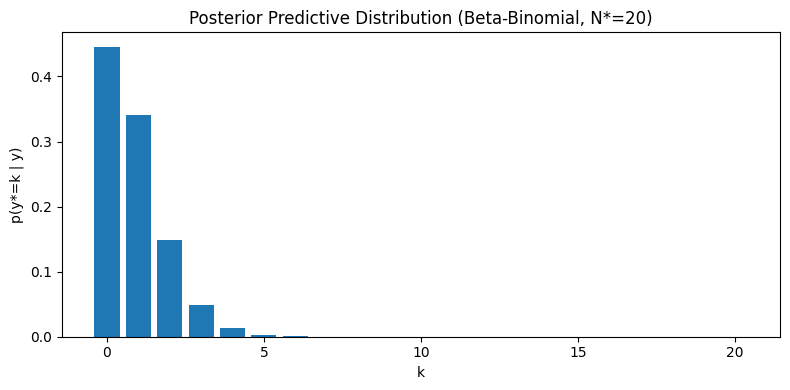

In [74]:
## How to use this during your exam:

# 1. **When to use this:** Any Part 1 question involving binary outcomes (clicks, purchases,
#    errors, classification) with a Beta prior. Look for phrases like "Beta(a0, b0) prior"
#    and a Binomial likelihood.
# 2. **Update the data:** Set N (total trials) and y (successes). Set a0, b0 for the prior
#    (uniform prior = a0=b0=1).
# 3. **Posterior:** Beta(a0 + y, b0 + N - y). Mean = a/(a+b).
# 4. **Credibility interval:** Uses scipy's beta.ppf directly — no need to look up Z-scores.
# 5. **Predictive:** BetaBinomial PMF from scipy.stats. P(y* >= 1) = 1 - P(y*=0).

# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
from scipy.stats import beta as beta_dist, betabinom
import numpy as np

# Observed data
N_input = 115   # Total trials (e.g. website visits)
y_input = 4     # Successes (e.g. purchases)

# Prior parameters (uniform = 1, 1)
a0_input = 1.0
b0_input = 1.0

# Future trials for the predictive distribution
N_star_input = 20

# Credibility interval level
level = 0.95  # e.g. 0.95 for 95%

# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
N  = int(N_input)
y  = int(y_input)
a0 = float(a0_input)
b0 = float(b0_input)
N_star = int(N_star_input)

# Posterior parameters
a_post = a0 + y
b_post = b0 + N - y

# Posterior mean, MAP, std
post_mean = a_post / (a_post + b_post)
post_map  = (a_post - 1) / (a_post + b_post - 2) if (a_post > 1 and b_post > 1) else float('nan')
post_std  = np.sqrt((a_post * b_post) / ((a_post + b_post)**2 * (a_post + b_post + 1)))

# Credibility interval
alpha_tail = (1.0 - level) / 2.0
lo = beta_dist.ppf(alpha_tail,   a_post, b_post)
hi = beta_dist.ppf(1-alpha_tail, a_post, b_post)

# Posterior predictive distribution (Beta-Binomial)
ks = np.arange(0, N_star + 1)
pred_probs = betabinom.pmf(ks, N_star, a_post, b_post)

# P(y* >= 1) = 1 - P(y* = 0)
prob_at_least_one = 1.0 - float(betabinom.pmf(0, N_star, a_post, b_post))

# Predictive mean and variance
pred_mean = N_star * a_post / (a_post + b_post)
pred_var  = N_star * a_post * b_post * (a_post + b_post + N_star) / \
            ((a_post + b_post)**2 * (a_post + b_post + 1))

# ==========================================
# 3. RESULTS
# ==========================================
print("--- BETA-BINOMIAL MODEL ---")
print(f"Prior:     Beta({a0}, {b0})")
print(f"Data:      y={y} successes in N={N} trials")
print(f"Posterior: Beta({a_post}, {b_post})")
print(f"\nPosterior Mean:  {post_mean:.4f}")
print(f"Posterior MAP:   {post_map:.4f}")
print(f"Posterior Std:   {post_std:.4f}")
print(f"{level*100:.0f}% Credibility Interval: [{lo:.4f}, {hi:.4f}]")

print(f"\n--- POSTERIOR PREDICTIVE (N*={N_star}) ---")
print(f"Predictive Mean:     {pred_mean:.4f}")
print(f"Predictive Variance: {pred_var:.4f}")
print(f"P(y* >= 1 | y):      {prob_at_least_one:.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.bar(ks, pred_probs)
plt.xlabel("k"); plt.ylabel("p(y*=k | y)")
plt.title(f"Posterior Predictive Distribution (Beta-Binomial, N*={N_star})")
plt.tight_layout(); plt.show()

# 10. Poisson Regression Predictive (via Sampling)

In [75]:
## How to use this during your exam:

# 1. **When to use this:** After running MAP + Laplace for a Poisson regression model,
#    when the exam asks for predictions at a new point x* — i.e. the distribution of
#    mu* = exp(f*) or y* ~ Poisson(mu*).
# 2. **Inputs:** x_star_input is the feature vector [1, x_value] (include the intercept!).
#    m and S come directly from your Laplace approximation cell above.
# 3. **What it computes:**
#    - p(f* | y) = N(x*^T m, x*^T S x*)
#    - mu* = exp(f*) (the expected count)
#    - y* ~ Poisson(mu*)  (the observed count)
# 4. **Run it:** Hit Shift+Enter for means, variances, and a credibility interval on y*.

# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
import numpy as np

# Test feature vector (e.g. [1, age] for age=30)
x_star_input = [1.0, 30.0]

# Posterior mean and covariance from Laplace approximation
# (In a real exam these come from your MAP/Laplace cell above)
m_input = [0.5, 0.02]         # posterior mean vector
S_input = [[0.1, 0.0],        # posterior covariance matrix
           [0.0, 0.001]]

# Sampling settings
n_samples = 5000
seed = 42
level = 0.90   # for the predictive credibility interval

x_star = np.array(x_star_input)
m_np   = np.array(m_input)
S_np   = np.array(S_input)

# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
rng = np.random.default_rng(seed)

# Predictive distribution of f* = x*^T w
mu_f  = float(x_star @ m_np)
var_f = float(x_star @ S_np @ x_star)
std_f = np.sqrt(var_f)

# Step 1: Sample f* ~ N(mu_f, var_f)
f_samples = rng.normal(loc=mu_f, scale=std_f, size=n_samples)

# Step 2: Transform to rate mu* = exp(f*)
mu_samples = np.exp(f_samples)

# Step 3: Sample y* | mu* ~ Poisson(mu*)
y_star_samples = rng.poisson(lam=mu_samples)

# Summary statistics
alpha_tail = (1.0 - level) / 2.0
lo = float(np.quantile(y_star_samples, alpha_tail))
hi = float(np.quantile(y_star_samples, 1.0 - alpha_tail))

# ==========================================
# 3. RESULTS
# ==========================================
print("--- POISSON REGRESSION PREDICTIONS ---")
print(f"Test point x*: {x_star_input}")
print(f"\np(f* | y):  N(mean={mu_f:.4f}, var={var_f:.4f})")
print(f"\nE[mu* | y]  = {np.mean(mu_samples):.4f}   (posterior mean of the rate)")
print(f"E[y*  | y]  = {np.mean(y_star_samples):.4f}   (posterior mean of the count)")
print(f"Std[y* | y] = {np.std(y_star_samples):.4f}")
print(f"\n{level*100:.0f}% Predictive Interval for y*: [{lo:.1f}, {hi:.1f}]")

--- POISSON REGRESSION PREDICTIONS ---
Test point x*: [1.0, 30.0]

p(f* | y):  N(mean=1.1000, var=1.0000)

E[mu* | y]  = 4.8603   (posterior mean of the rate)
E[y*  | y]  = 4.8916   (posterior mean of the count)
Std[y* | y] = 6.8158

90% Predictive Interval for y*: [0.0, 16.0]


# 11.  R-hat and ESS (Convergence Diagnostics)

In [76]:
## How to use this during your exam:

# 1. **When to use this:** Any time you run multiple MCMC chains and the exam asks you to
#    "assess convergence" or report R-hat and ESS (e.g. Exam Part 5 with HMC/Metropolis).
# 2. **Input format:** chains should be shape (num_chains, num_samples, num_params).
#    If you only ran one chain, you cannot compute R-hat — you need at least 2.
# 3. **Interpretation:**
#    - R-hat < 1.1  → chains have mixed (converged)
#    - ESS large    → samples are nearly independent (good)
#    - ESS small    → high autocorrelation (increase iterations or tune proposal)
# 4. **Run it:** Pass in your raw chains (after warmup discard) and read off the values.

# ==========================================
# 1. INPUTS (Change these for your exam!)
# ==========================================
import numpy as np

# chains: shape (num_chains, num_samples, num_params)
# In a real exam: stack your individual chains using np.stack([chain1, chain2], axis=0)
# Example dummy chains for illustration:
np.random.seed(0)
dummy_chain = np.random.randn(2, 1000, 2)  # 2 chains, 1000 samples, 2 params
chains_input = dummy_chain

# ==========================================
# 2. CALCULATIONS (Do not change this part)
# ==========================================
chains_np = np.array(chains_input)  # shape: (M, S, D)
M, S, D = chains_np.shape

# --- R-hat ---
chain_means  = chains_np.mean(axis=1)          # (M, D)
grand_mean   = chain_means.mean(axis=0)        # (D,)
B = S / (M - 1) * np.sum((chain_means - grand_mean)**2, axis=0)  # between-chain var
W = np.mean(chains_np.var(axis=1, ddof=1), axis=0)               # within-chain var
var_hat = ((S - 1) / S) * W + (1 / S) * B
R_hat = np.sqrt(var_hat / W)

# --- ESS (using autocorrelation via FFT) ---
def compute_ess(chain_1d):
    """ESS for a single 1D chain using autocorrelation."""
    n = len(chain_1d)
    x = chain_1d - chain_1d.mean()
    # Autocorrelation via FFT
    f = np.fft.fft(x, n=2*n)
    acf_full = np.fft.ifft(f * np.conj(f)).real[:n]
    acf = acf_full / acf_full[0]
    # Sum positive autocorrelations (stop at first negative)
    rho_sum = 0.0
    for t in range(1, n):
        if acf[t] < 0:
            break
        rho_sum += acf[t]
    return n / (1 + 2 * rho_sum)

# Pool all chains together for ESS calculation
all_samples = chains_np.reshape(-1, D)  # (M*S, D)
ESS = np.array([compute_ess(all_samples[:, d]) for d in range(D)])

# ==========================================
# 3. RESULTS
# ==========================================
print("--- CONVERGENCE DIAGNOSTICS ---")
print(f"Chains: {M}  |  Samples per chain: {S}  |  Parameters: {D}")
print(f"\n{'Param':<10} {'R-hat':<12} {'ESS':<12} {'Converged?'}")
print("-" * 45)
for d in range(D):
    converged = "YES" if R_hat[d] < 1.1 else "NO — increase iterations"
    print(f"Param {d:<4}  {R_hat[d]:<12.4f} {ESS[d]:<12.1f} {converged}")

print(f"\nRule of thumb: R-hat < 1.1 → converged. ESS > 100 → reliable estimates.")

--- CONVERGENCE DIAGNOSTICS ---
Chains: 2  |  Samples per chain: 1000  |  Parameters: 2

Param      R-hat        ESS          Converged?
---------------------------------------------
Param 0     1.0000       2000.0       YES
Param 1     0.9995       1988.6       YES

Rule of thumb: R-hat < 1.1 → converged. ESS > 100 → reliable estimates.


# 12. CAVI (Coordinate Ascent Variational Inference)

Iter   m1         v1         m2         v2         ELBO
-------------------------------------------------------
1      3.0000     0.5000     0.0000     1.0000     10.4913
2      3.0000     0.5000     0.0000     1.0000     10.4913
3      3.0000     0.5000     0.0000     1.0000     10.4913
4      3.0000     0.5000     0.0000     1.0000     10.4913
5      3.0000     0.5000     0.0000     1.0000     10.4913
6      3.0000     0.5000     0.0000     1.0000     10.4913
7      3.0000     0.5000     0.0000     1.0000     10.4913
8      3.0000     0.5000     0.0000     1.0000     10.4913
9      3.0000     0.5000     0.0000     1.0000     10.4913
10     3.0000     0.5000     0.0000     1.0000     10.4913
11     3.0000     0.5000     0.0000     1.0000     10.4913
12     3.0000     0.5000     0.0000     1.0000     10.4913
13     3.0000     0.5000     0.0000     1.0000     10.4913
14     3.0000     0.5000     0.0000     1.0000     10.4913
15     3.0000     0.5000     0.0000     1.0000     10.4913
16 

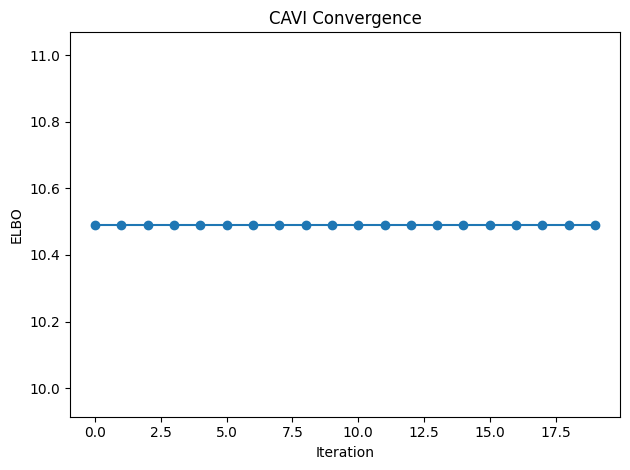

In [77]:
## How to use this during your exam:

# 1. **When to use this:** When the exam gives you a log joint ln p(y, w) and asks you to
#    run CAVI with a mean-field factorisation q(w) = q(w1)*q(w2)*...
# 2. **Write the update functions:** The key step is implementing `update_q1` and `update_q2`.
#    Each update computes the new mean and variance by matching the functional form of
#    ln q*(wk) = E_{q(-k)}[ln p(y,w)] + const to a Gaussian: -1/(2v)(w-m)^2.
# 3. **Monitor convergence:** Watch the ELBO increase each iteration. It must never decrease.
# 4. **Exam tip:** The update equations are almost always given analytically in the question.
#    Your job is to plug in the current values of the OTHER parameter's mean and iterate.

# ==========================================
# 1. INPUTS & UPDATE RULES (Change for your exam!)
# ==========================================
import numpy as np

# Example from lecture slides:
# ln p(y, w) = -w1^2 - 0.5*w2^2 + w1*w2 + 6*w1 - 3*w2
# Update rules (derived analytically from CAVI):
#   q*(w1) = N(w1 | 3 + 0.5*m2, 0.5)   → variance v1 = 0.5 always
#   q*(w2) = N(w2 | m1 - 3,     1.0)   → variance v2 = 1.0 always

# Initial variational parameters
m1_init = 0.0   # initial mean for q(w1)
m2_init = 0.0   # initial mean for q(w2)
v1_init = 0.5   # variance for q(w1) — often fixed by the model
v2_init = 1.0   # variance for q(w2) — often fixed by the model

n_iter = 20    # number of CAVI iterations

# MOST IMPORTANT: define the update functions for your specific model
# (change these to match the exam's log joint!)
def update_q1(m2):
    """Returns (new_mean, new_variance) for q(w1) given current E[w2]=m2"""
    new_v1 = 0.5
    new_m1 = 3.0 + 0.5 * m2
    return new_m1, new_v1

def update_q2(m1):
    """Returns (new_mean, new_variance) for q(w2) given current E[w1]=m1"""
    new_v2 = 1.0
    new_m2 = m1 - 3.0
    return new_m2, new_v2

# ELBO function for monitoring (change to match your log joint!)
def compute_elbo(m1, v1, m2, v2):
    # E_q[ln p(y,w)] for ln p = -w1^2 - 0.5*w2^2 + w1*w2 + 6*w1 - 3*w2
    # E[w1^2] = v1 + m1^2,  E[w2^2] = v2 + m2^2,  E[w1*w2] = m1*m2
    E_log_joint = (-(v1 + m1**2)
                   - 0.5*(v2 + m2**2)
                   + m1*m2
                   + 6*m1 - 3*m2)
    # Entropy H[q] = 0.5 * sum(log(2*pi*e*v_i))
    entropy = 0.5 * (np.log(2*np.pi*np.e*v1) + np.log(2*np.pi*np.e*v2))
    return E_log_joint + entropy

# ==========================================
# 2. CAVI LOOP (Do not change this part)
# ==========================================
m1, v1 = m1_init, v1_init
m2, v2 = m2_init, v2_init
elbo_history = []

print(f"{'Iter':<6} {'m1':<10} {'v1':<10} {'m2':<10} {'v2':<10} {'ELBO'}")
print("-" * 55)

for i in range(n_iter):
    # Update q(w1) using current E[w2] = m2
    m1, v1 = update_q1(m2)
    # Update q(w2) using updated E[w1] = m1
    m2, v2 = update_q2(m1)
    
    elbo = compute_elbo(m1, v1, m2, v2)
    elbo_history.append(elbo)
    print(f"{i+1:<6} {m1:<10.4f} {v1:<10.4f} {m2:<10.4f} {v2:<10.4f} {elbo:.4f}")

# ==========================================
# 3. RESULTS
# ==========================================
print("\n--- CAVI FINAL RESULT ---")
print(f"q(w1) = N(w1 | m1={m1:.4f}, v1={v1:.4f})")
print(f"q(w2) = N(w2 | m2={m2:.4f}, v2={v2:.4f})")
print(f"Final ELBO: {elbo_history[-1]:.4f}")

import matplotlib.pyplot as plt
plt.plot(elbo_history, marker='o')
plt.xlabel("Iteration"); plt.ylabel("ELBO")
plt.title("CAVI Convergence"); plt.tight_layout(); plt.show()